 $$ p(x ; \mu,\sigma ^2) = \frac{1}{\sqrt{2 \pi \sigma ^2}}\exp^{ - \frac{(x - \mu)^2}{2 \sigma ^2} }$$

 $$\mu_i = \frac{1}{m} \sum_{j=1}^m x_i^{(j)}$$

$$\sigma_i^2 = \frac{1}{m} \sum_{j=1}^m (x_i^{(j)} - \mu_i)^2$$

In [1]:
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn import metrics

sns.set_theme('paper')

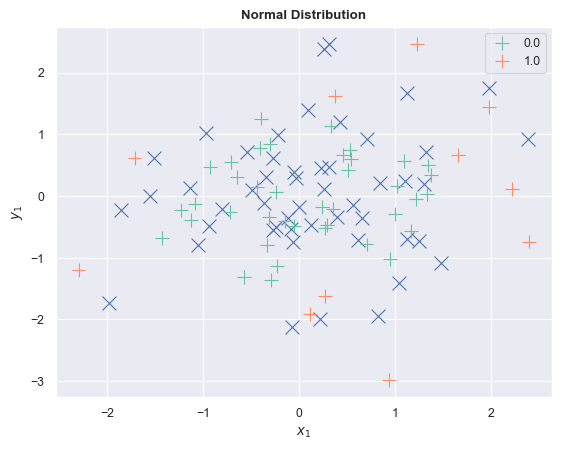

In [2]:
np.random.seed(10)
X = np.random.standard_normal((100, 2))
X_train = X[:50]
X_cv = X[50:]
y_cv = np.zeros(len(X_cv), dtype=np.float64)
for i in range(len(y_cv)):
    if (X_cv[i, 0] < -1.6 or X_cv[i, 0] > 1.6 or
        X_cv[i, 1] < -1.6 or X_cv[i, 1] > 1.6):
        y_cv[i] = 1
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], s=100, c='b', marker='x')
sns.scatterplot(x=X_cv[:, 0], y=X_cv[:, 1], s=100, hue=y_cv, palette='Set2', marker='+',)
plt.title('Normal Distribution', fontweight='bold')
plt.xlabel('$x_1$')
plt.ylabel('$y_1$')
plt.show()

In [3]:
mu = np.mean(X_train, axis=0)
var = np.mean((X_train - mu)**2, axis=0)

In [4]:

# def multivariate_gaussian(X):
#     """
#     Computes the probability
#     density function of the examples X under the multivariate gaussian
#     distribution with parameters mu and var. If var is a matrix, it is
#     treated as the covariance matrix. If var is a vector, it is treated
#     as the var values of the variances in each dimension (a diagonal
#     covariance matrix
#     """

#     k = len(mu)

#     if var.ndim == 1:
#         var = np.diag(var)

#     X = X - mu
#     p = (2* np.pi)**(-k/2) * np.linalg.det(var)**(-0.5) * \
#         np.exp(-0.5 * np.sum(np.matmul(X, np.linalg.pinv(var)) * X, axis=1))

#     return p

# Use the simple one
def univariate_gaussian(X):
    # 1 / sqrt(2 * pi * σ²)
    coefficient = 1 / np.sqrt(2 * np.pi * var)

    # -((x - μ)² / (2 * σ²))
    exponent = -((X - mu) ** 2) / (2 * var)

    return coefficient * np.exp(exponent)


def multivariate_gaussian(X):
    return np.prod(univariate_gaussian(X), axis=1)

In [5]:
def select_threshold(y_val, p_val):
    best_epsilon = 0
    best_F1 = 0
    F1 = 0

    step_size = (max(p_val) - min(p_val)) / 5000

    for epsilon in np.arange(min(p_val), max(p_val), step_size):
        tp = np.sum((p_val < epsilon) & (y_val == 1))
        fp = np.sum((p_val < epsilon) & (y_val == 0))
        fn = np.sum((p_val >= epsilon) & (y_val == 1))
        prec = tp / (tp + fp)
        rec = tp / (tp + fn)
        F1 = 2 * prec * rec / (prec + rec)

        if F1 > best_F1:
            best_F1 = F1
            best_epsilon = epsilon

    return best_epsilon, best_F1

In [6]:
p_cv = multivariate_gaussian(X_cv)
epsilon, f1_score = select_threshold(y_cv, p_cv)
print("Best epsilon", epsilon)
print("Best F1 score", f1_score)

Best epsilon 0.04798326264364103
Best F1 score 0.9565217391304348


/var/folders/92/54csr3px3gsbnmpb1xg1cfmc0000gp/T/ipykernel_60020/2055781332.py:12: RuntimeWarning: invalid value encountered in scalar divide
  prec = tp / (tp + fp)


In [7]:
print(metrics.classification_report(y_cv, p_cv < epsilon))

              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99        39
         1.0       0.92      1.00      0.96        11

    accuracy                           0.98        50
   macro avg       0.96      0.99      0.97        50
weighted avg       0.98      0.98      0.98        50



In [8]:
def predict(X):
    p = multivariate_gaussian(X)
    return p < epsilon

y_pred = predict(X)

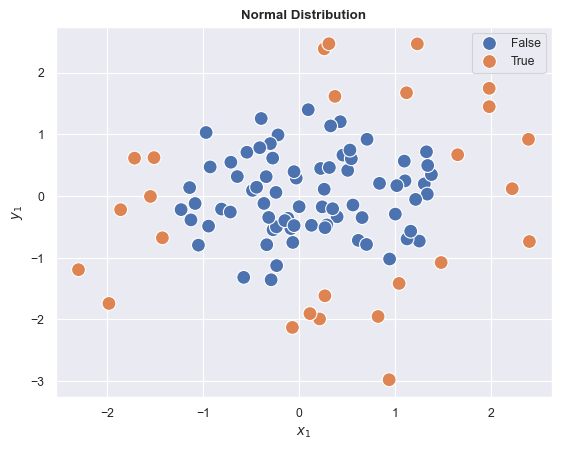

In [9]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], s=100, hue=y_pred, marker='o')
plt.title('Normal Distribution', fontweight='bold')
plt.xlabel('$x_1$')
plt.ylabel('$y_1$')
plt.show()